In [1]:
# 📦 Install Biopython

!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 32.5 MB/s eta 0:00:00a 0:00:01


In [2]:
# 📚 Import necessary modules

from Bio.KEGG import REST, Gene

In [3]:
# Fetch the target gene record (TP53)
# Human-specific ID for p53 (hsa:7157)

request = REST.kegg_get("hsa:7157")

In [4]:
# Save the raw KEGG data to a file
# Save the data as a .txt file for future reference or debugging

with open("hsa_7157.txt", "w") as f:
    f.write(request.read())

In [5]:
# Parse the KEGG Gene record
# Use the Gene.parse to read the local file and convert it into a record object

records = Gene.parse(open("hsa_7157.txt"))
record = list(records)[0]

In [6]:
# Extract and Display Gene Information
# Pull the clean name and the functional definition from the orthology tuple

gene_name = record.name[0]
gene_definition = record.orthology[0][1]

print(f"Name: {gene_name}")
print(f"Definition: {gene_definition}")

Name: (RefSeq) cellular tumor antigen p53 isoform a
Definition: tumor protein p53


In [7]:
# Scan the saved gene file to dynamically extract the 'p53 signaling pathway' ID.

print(f"{'ID':<10} | Selected Pathway Name")
print("-" * 35)

found_id = ""

with open("hsa_7157.txt", "r") as f:
    for line in f:
        # Filter for p53 pathway lines using the 'hsa' prefix
        if "p53" in line and "hsa" in line:
            parts = line.replace("PATHWAY", "").split()
            
            if parts[0].startswith("hsa"):
                found_id = parts[0]
                # Clean name by removing technical tags (e.g., [BR:hsa04115])
                name = " ".join(parts[1:]).split("[")[0]
                
                print(f"{found_id:<10} | {name}")
                break # Exit once the primary pathway is found

print(f"\nAutomated ID discovery: {found_id}")

ID         | Selected Pathway Name
-----------------------------------
hsa04115   | p53 signaling pathway

Automated ID discovery: hsa04115


Project Focus: hsa04115 | p53 signaling pathway
--------------------------------------------------


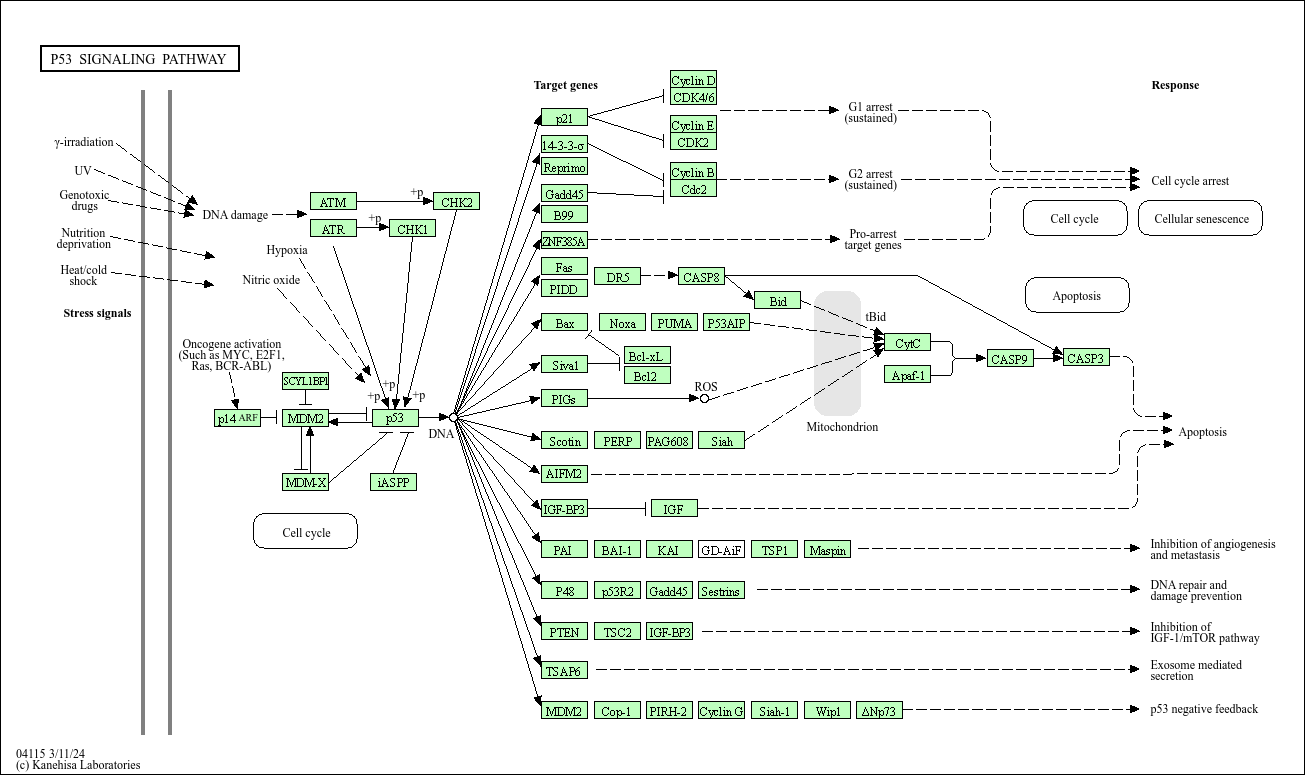

In [9]:
# Fetch the pathway map image from KEGG and display it in the notebook.

from IPython.display import Image, display

# 1. Request the map image from KEGG using the discovered ID
map_request = REST.kegg_get(found_id, "image")
map_img = map_request.read()

# 2. Display the result
print(f"Project Focus: {found_id} | p53 signaling pathway")
print("-" * 50)
display(Image(map_img))